# Equivalent Widths with PopStar SSP spectra

This tutorial shows how to use `pst.observables.EquivalentWidth` with PopStar SSP models.

You will learn how to:

- load PopStar SSP spectra,
- compute a Lick-style equivalent width for one spectrum,
- include spectral uncertainties,
- compute equivalent widths for the full SSP grid efficiently.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u

from pst.SSP import PopStar
from pst.observables import EquivalentWidth

## 1. Load PopStar

By default, PST looks for PopStar files in its SSP data directory.

In [2]:
ssp = PopStar(IMF="cha", nebular=False, verbose=False)
print("wavelength shape:", ssp.wavelength.shape)
print("L_lambda shape   :", ssp.L_lambda.shape)
print("metallicities    :", ssp.metallicities.value)
print("log(age/yr) range:", ssp.log_ages_yr.min().value, "to", ssp.log_ages_yr.max().value)

wavelength shape: (1229,)
L_lambda shape   : (6, 106, 1229)
metallicities    : [0.0001 0.0004 0.004  0.008  0.02   0.05  ]
log(age/yr) range: 5.0 to 10.18


`ssp.L_lambda` has shape `(n_metallicity, n_age, n_wavelength)`.

`EquivalentWidth.compute_ew` expects the spectral axis first for multidimensional arrays, so later we will move axes accordingly.

## 2. Compute EW for one SSP spectrum

Here we use the built-in Hbeta Lick index (`lick_hb`).

In [3]:
hb = EquivalentWidth.from_name("lick_hb")

# Pick one spectrum near solar metallicity and ~1 Gyr
i_z = np.argmin(np.abs(ssp.metallicities.value - 0.02))
i_age = np.argmin(np.abs(ssp.log_ages_yr.value - 9.0))

spectrum = ssp.L_lambda[i_z, i_age]
ew_hb, _ = hb.compute_ew(ssp.wavelength, spectrum)

print(f"Selected metallicity Z = {ssp.metallicities[i_z]:.4f}")
print(f"Selected log(age/yr) = {ssp.log_ages_yr[i_age]:.2f}")
print(f"Hbeta equivalent width = {ew_hb:.4f}")

Selected metallicity Z = 0.0200
Selected log(age/yr) = 9.00
Hbeta equivalent width = 2.6940 Angstrom


## 3. Include spectral uncertainty

If you have per-wavelength uncertainties, pass them through `spectra_err`.

Below we create a toy uncertainty of 5% of the flux.

In [4]:
spectrum_err = 0.05 * spectrum
ew_hb, ew_hb_err = hb.compute_ew(ssp.wavelength, spectrum, spectra_err=spectrum_err)
print(f"Hbeta EW = {ew_hb:.4f}")
print(f"Hbeta EW uncertainty = {ew_hb_err:.4f}")

Hbeta EW = 2.6940 Angstrom
Hbeta EW uncertainty = 0.7759 Angstrom


You can also visualise the result using the built-in method `plot_ew`

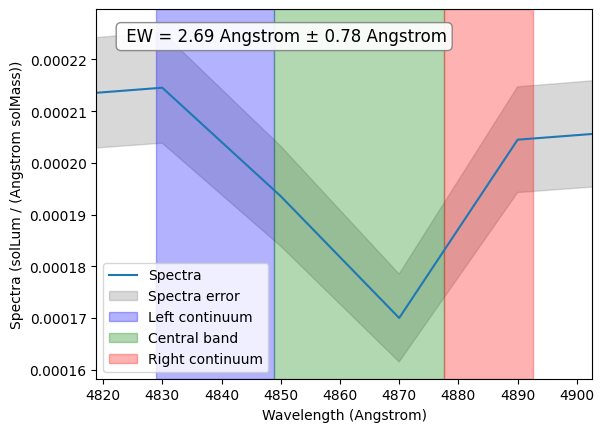

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Wavelength (Angstrom)', ylabel='Spectra (solLum / (Angstrom solMass))'>)

In [5]:
hb.plot_ew(ssp.wavelength, spectrum, spectra_err=spectrum_err, show=True)

## 4. Compute EW for the full PopStar grid (vectorized)

For speed, use one call over the whole cube.

`compute_ew` expects shape `(n_wavelength, ...)`, so we move the wavelength axis to the first position.

In [6]:
spectra_cube = np.moveaxis(ssp.L_lambda, -1, 0)
spectra_err_cube = 0.05 * spectra_cube

hb_grid, hb_grid_err = hb.compute_ew(ssp.wavelength, spectra_cube, spectra_err=spectra_err_cube)

print("EW grid shape:", hb_grid.shape)
print("Expected shape:", (ssp.metallicities.size, ssp.ages.size))

EW grid shape: (6, 106)
Expected shape: (6, 106)


## 5. Visualize EW(Hbeta) as a function of age

We plot a few metallicities from the grid computed above.

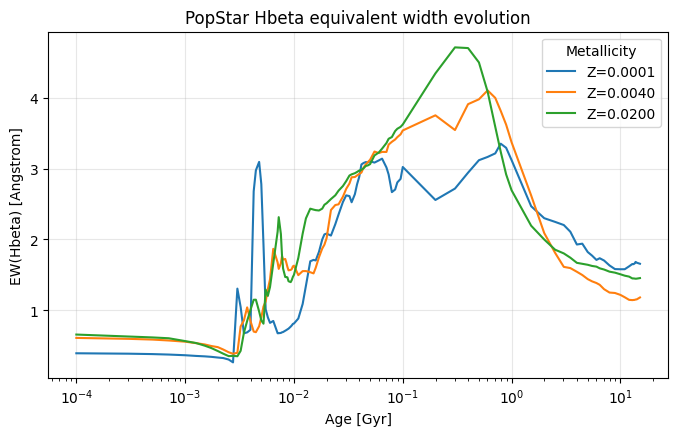

In [7]:
ages_gyr = ssp.ages.to_value(u.Gyr)

fig, ax = plt.subplots(figsize=(8, 4.5))
for iz in [0, 2, 4]:
    ax.plot(ages_gyr, hb_grid[iz].value, label=f"Z={ssp.metallicities[iz].value:.4f}")

ax.set_xscale("log")
ax.set_xlabel("Age [Gyr]")
ax.set_ylabel(f"EW(Hbeta) [{hb_grid.unit}]")
ax.set_title("PopStar Hbeta equivalent width evolution")
ax.grid(alpha=0.3)
ax.legend(title="Metallicity")
plt.show()

## 6. Define your own index windows

You can also define custom equivalent-width windows directly:

In [8]:
custom_index = EquivalentWidth(
    left_wl_range=(4820, 4840),
    central_wl_range=(4848, 4878),
    right_wl_range=(4885, 4920),
)

custom_ew, custom_ew_err = custom_index.compute_ew(
    ssp.wavelength,
    spectrum,
    spectra_err=spectrum_err,
)

print(f"Custom index EW = {custom_ew:.4f}")
print(f"Custom index uncertainty = {custom_ew_err:.4f}")

Custom index EW = 2.7557 Angstrom
Custom index uncertainty = 0.7424 Angstrom


## 7. Compute Multiple Indices with EquivalentWidthList

`EquivalentWidthList` allows you to evaluate several spectral indices in a single call using the same wavelength grid and spectrum.

In [9]:
from pst.observables import EquivalentWidthList, show_available_equivalent_widths

# Display the built-in equivalent-width indices available in PST.
show_available_equivalent_widths()

Available equivalent-width indices:
 - name: BH_CNB, left_wl_range: (3785.0, 3810.0), right_wl_range: (3910.0, 3925.0), central_wl_range: (3810.0, 3910.0)
 - name: BH_HplusK, left_wl_range: (3910.0, 3925.0), right_wl_range: (3995.0, 4010.0), central_wl_range: (3925.0, 3995.0)
 - name: Lick_CN1, left_wl_range: (4080.125, 4117.625), right_wl_range: (4244.125, 4284.125), central_wl_range: (4142.125, 4177.125)
 - name: Lick_CN2, left_wl_range: (4083.875, 4096.375), right_wl_range: (4244.125, 4284.125), central_wl_range: (4142.125, 4177.125)
 - name: BH_CaI, left_wl_range: (4200.0, 4215.0), right_wl_range: (4245.0, 4260.0), central_wl_range: (4215.0, 4245.0)
 - name: Lick_Ca4227, left_wl_range: (4211.0, 4219.75), right_wl_range: (4241.0, 4251.0), central_wl_range: (4222.25, 4234.75)
 - name: Lick_G4300, left_wl_range: (4266.375, 4282.625), right_wl_range: (4318.875, 4332.125), central_wl_range: (4281.375, 4316.375)
 - name: BH_G, left_wl_range: (4275.0, 4285.0), right_wl_range: (4315.0, 432

Given the relatively low spectral resolution of these SSP models, we will focus on broader absorption features.

In [10]:
ew_list = EquivalentWidthList.from_atlas(["Lick_Mg1", "Lick_TiO2"])

ew_values, ew_errors = ew_list.compute_ew(
    ssp.wavelength,
    spectrum,
    spectra_err=spectrum_err,
)

for name, value, err in zip(ew_list.names, ew_values, ew_errors):
    print(f"{name:>8s}: EW = {value:.4f}, uncertainty = {err:.4f}")

Lick_Mg1: EW = 1.4948 Angstrom, uncertainty = 1.6685 Angstrom
Lick_TiO2: EW = 1.3906 Angstrom, uncertainty = 1.9894 Angstrom


## 8. Measuring the 4000 Angstrom Break

`D4000Index` is a flux-ratio diagnostic that measures the Balmer 4000 Angstrom break using two fixed wavelength windows.

In PST, the index is defined as:
- blue window: 3750-3950 Angstrom
- red window: 4050-4250 Angstrom

The index is computed as red/blue mean flux.

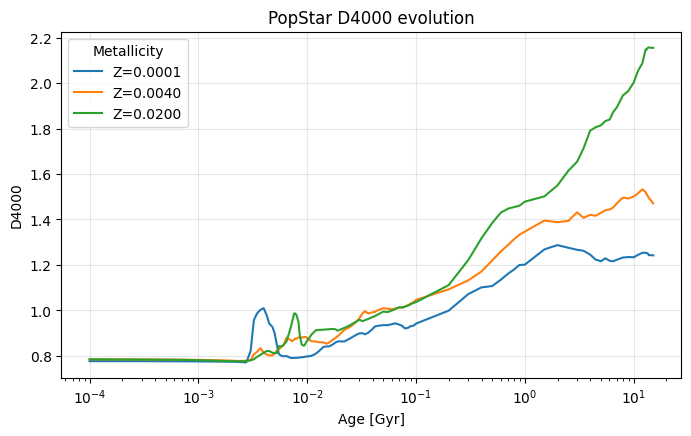

In [11]:
from pst.observables import D4000Index

d4000 = D4000Index()

d4000_value, d4000_err = d4000.compute_flux_ratio(
    ssp.wavelength,
    spectra_cube,
    spectra_err=spectra_err_cube,
)

fig, ax = plt.subplots(figsize=(8, 4.5))
for iz in [0, 2, 4]:
    ax.plot(ages_gyr, d4000_value[iz].value, label=f"Z={ssp.metallicities[iz].value:.4f}")

ax.set_xscale("log")
ax.set_xlabel("Age [Gyr]")
ax.set_ylabel(f"D4000")
ax.set_title("PopStar D4000 evolution")
ax.grid(alpha=0.3)
ax.legend(title="Metallicity")
plt.show()